In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid')

In [4]:
df = pd.read_csv('/Users/kultumlhabaik/Documents/data-mining-final-project/data/raw/spotify_songs_JA.csv')
print(df.shape)
df.head()

(32833, 23)


,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,playlist_subgenre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.748,0.916,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.726,0.815,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.675,0.931,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.718,0.930,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.650,0.833,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


In [5]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  32833 non-null  str    
 1   track_name                32828 non-null  str    
 2   track_artist              32828 non-null  str    
 3   track_popularity          32833 non-null  int64  
 4   track_album_id            32833 non-null  str    
 5   track_album_name          32828 non-null  str    
 6   track_album_release_date  32833 non-null  str    
 7   playlist_name             32833 non-null  str    
 8   playlist_id               32833 non-null  str    
 9   playlist_genre            32833 non-null  str    
 10  playlist_subgenre         32833 non-null  str    
 11  danceability              32833 non-null  float64
 12  energy                    32833 non-null  float64
 13  key                       32833 non-null  int64  
 14  loudness         

In [ ]:
# there are 5 null values in track_name, track_artist, track_album_name so we will drop them from dataset entirely 
#since we dont know who they belong to

df = df.dropna(subset=['track_artist', 'track_name', 'track_album_name'])

#new total amount of rows
print(len(df))



32828


In [ ]:
#Missing Values
#amount of blank/NaN values are in each column
missing = df.isnull().sum()
#print columns only with missing values
print(missing[missing>0])

#find what percentage of each column has missing values
print('\nAs percentage of total rows:')
print((missing[missing > 0] / len(df) * 100).round(2))


#*there were no missing values in the whole dataset 

Series([], dtype: int64)

As percentage of total rows:
Series([], dtype: float64)


In [10]:
#Find Duplicates 

# check if there are any duplicated rows
print('Duplicate rows:', df.duplicated().sum())

# Checking if same track_id appears more than once
print('Total rows:       ', len(df))
unique_songs = df['track_id'].nunique()
print('Unique track_ids: ', unique_songs) # how many unique songs exist in the dataset
duplicates = df.duplicated(subset='track_id').sum()
print('Duplicate track_ids:', duplicates) #how many songs appear in more than one playlist

Duplicate rows: 0
Total rows:        32828
Unique track_ids:  28352
Duplicate track_ids: 4476


In [11]:
#GET only the year for each release date
#take first 4 characters which is the year then convert string into an integer
df['release_year'] = (df['track_album_release_date'].str[:4].pipe(pd.to_numeric, errors='coerce'))

print('Earliest year:', df['release_year'].min())
print('Latest year:  ', df['release_year'].max())
print('Unparseable dates (NaN):', df['release_year'].isnull().sum())

Earliest year: 1957
Latest year:   2020
Unparseable dates (NaN): 0


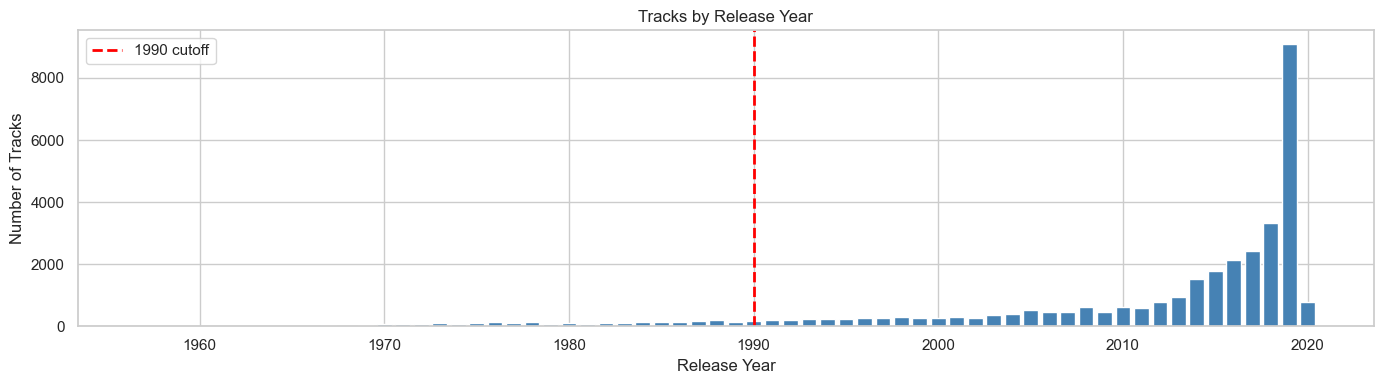

In [ ]:
# amount of tracks were released each year
year_counts = df['release_year'].value_counts().sort_index()

plt.figure(figsize=(14, 4))
plt.bar(year_counts.index, year_counts.values, color='steelblue')

# red dotted line showing where we will cut off the data
plt.axvline(1990, color='red', linestyle='--', linewidth=2, label='1990 cutoff')

plt.xlabel('Release Year')
plt.ylabel('Number of Tracks')
plt.title('Tracks by Release Year')
plt.legend()
plt.tight_layout()
plt.show()

## Findings — Release Year Distribution

**Before 1990:**
Very little data with an almost flat distribution. There are not enough tracks per artist to build reliable year-by-year profiles, which is why we cut off everything before 1990.

**After 1990:**
Steady growth in tracks released per year, with a large spike around 2018-2019. This aligns with the peak of music streaming where artists were releasing more music than before.

**2020 Drop:**
The sharp drop at 2020 does not mean fewer songs were released that year. It just means the dataset was collected halfway through 2020, so that year is incomplete compared to previous years.

**Decision:**
We set our cutoff at 1990 because data before that point there is not enough information to support artist modeling. After filtering the years, we now have 30,381 rows representing 10,326 different artists.

In [14]:
# dataset filtered to only 1990 and later
df_1990 = df[df['release_year'] >= 1990].copy()
print('Rows after 1990 filter:', len(df_1990))
#total amout of artist in new scope of dataset
print('Total artists:', df_1990['track_artist'].nunique())

# count for each artist, the amount of different years they released music in
active_years = df_1990.groupby('track_artist')['release_year'].nunique()

print('\nHow many artists qualify at each minimum years cutoff:')
#for i in num or active years
for i in [1, 2, 3, 4, 5]:
    n = (active_years >= i).sum()
    print(f'  at least {i} active years: {n} artists')

Rows after 1990 filter: 30381
Total artists: 10326

How many artists qualify at each minimum years cutoff:
  at least 1 active years: 10326 artists
  at least 2 active years: 2819 artists
  at least 3 active years: 1229 artists
  at least 4 active years: 641 artists
  at least 5 active years: 369 artists


In [16]:
# we will only use who have at least 3 active years because we need multiple years of data to study the trends

#filter data to artists with 3 active years 
artists_3_years = active_years[active_years >= 3].index.tolist()

print('Total amount of artists:', len(artists_3_years))

Total amount of artists: 1229


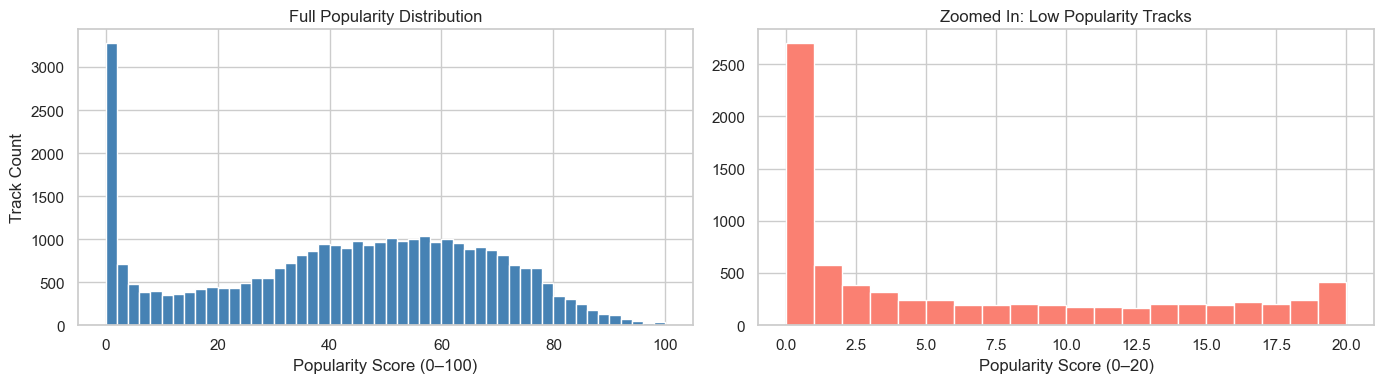

count    32828.000000
mean        42.483551
std         24.980476
min          0.000000
25%         24.000000
50%         45.000000
75%         62.000000
max        100.000000
Name: track_popularity, dtype: float64

Zero-popularity tracks: 2,698
As % of dataset:        8.2%


In [18]:
# track_popularity (0–100) is used to define artist decline

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left plot: full distribution
axes[0].hist(df['track_popularity'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Popularity Score (0–100)')
axes[0].set_ylabel('Track Count')
axes[0].set_title('Full Popularity Distribution')

# Right plot: zoomed into 0–20 to see the zero-popularity spike clearly
axes[1].hist(df[df['track_popularity'] <= 20]['track_popularity'],
             bins=20, color='salmon', edgecolor='white')
axes[1].set_xlabel('Popularity Score (0–20)')
axes[1].set_title('Zoomed In: Low Popularity Tracks')

plt.tight_layout()
plt.show()

# Summary stats
print(df['track_popularity'].describe())

# Zero-popularity tracks are a known Spotify data issue and can drag down the average and show false decline signals
print(f'\nZero-popularity tracks: {(df["track_popularity"] == 0).sum():,}')
print(f'As % of dataset:        {(df["track_popularity"] == 0).mean() * 100:.1f}%')

## Findings — Popularity Distribution

**Left Chart (Full Popularity Distribution):**
There are 2,698 tracks with zero popularity, represented by the large spike at 0. This is a problem because zero-popularity tracks could create fake decline signals in our artist profiles. Everything else follows a rough bell curve peaking around 50-65, which is normal for a playlist-based dataset.

**Right Chart (Zoomed In: Low Popularity Tracks):**
Confirms the spike at 0 is much larger than nearby scores. Popularity scores of 1 and 2 drop off sharply, meaning the zero scores are not just "very low popularity" but likely a separate data issue entirely.

**Decision:**
Tracks with a popularity score of exactly zero were excluded from analysis. The abnormal spike at zero relative to scores of 1-5 suggests these values may reflect a data collection artifact rather than genuine popularity measurements. This affects 2,698 tracks (8.2% of the dataset).

In [19]:
# remove tracks with zero popularity because keeping them could create fake decline signals for each artist

df_1990 = df_1990[df_1990['track_popularity'] > 0].copy()

print('Rows after removing zero-popularity tracks:', len(df_1990))
print('Zero-popularity tracks remaining:', (df_1990['track_popularity'] == 0).sum())

Rows after removing zero-popularity tracks: 27791
Zero-popularity tracks remaining: 0


In [ ]:
# this dataset only has 6 broad genres and 24 subgenres
# they come from which playlist the track was pulled from
# not from spotifys actual genre system, so they are quite broad

print('Broad Genres')  #pop, rap, rock, r&b, edm, latin
print(df_1990['playlist_genre'].value_counts())

print('\n Subgenres') #within each broader genre
print(df_1990['playlist_subgenre'].value_counts())

Broad Genres
playlist_genre
edm      5316
rap      5239
pop      5061
latin    4743
r&b      4661
rock     2771
Name: count, dtype: int64

 Subgenres
playlist_subgenre
indie poptimism              1565
southern hip hop             1463
progressive electro house    1439
latin hip hop                1421
pop edm                      1409
neo soul                     1406
electro house                1385
hip hop                      1317
dance pop                    1291
tropical                     1275
urban contemporary           1256
trap                         1253
hip pop                      1215
gangster rap                 1206
latin pop                    1172
electropop                   1167
big room                     1083
post-teen pop                1038
hard rock                    1036
reggaeton                     875
new jack swing                784
permanent wave                766
classic rock                  569
album rock                    400
Name: count, dty

## Findings — Genre Breakdown
Rock is noticeably underrepresented compared to other genres. This means rock artists will have less data in our models.

24 subgenres total, ranging from 1,565 to 400 tracks each.

These genre labels come from playlist, not sn actual spotify genre system, making them too broad for meaningful genre diversity analysis.
This is why we will later join with dataset_M.csv which contains 114 fine-grained genre labels for richer genre analysis.

In [ ]:
# manually verify that data is accurate by picking famous artists whose career timelines we can fact-check
def show_trajectory(artist_name):
    # rows belonging to this specific artist
    subset = df_1990[df_1990['track_artist'] == artist_name]
    #artist isnt in our dataset at all
    if subset.empty:
        print(f'{artist_name} not found in dataset')
        return
    
    trajectory = (subset.groupby('release_year')['track_popularity'].agg(mean_popularity='mean', track_count='count').round(1))
    print(f'\n{artist_name}')
    print(trajectory.to_string())

show_trajectory('Ed Sheeran')
show_trajectory('Drake')
show_trajectory('Ariana Grande')


Ed Sheeran
              mean_popularity  track_count
release_year                              
2011                     50.0            1
2013                     62.0            3
2014                     70.0            7
2015                     53.0            1
2017                     75.2           13
2018                     53.0            1
2019                     78.9           42

Drake
              mean_popularity  track_count
release_year                              
2009                     23.7            3
2010                     69.0            3
2011                     67.6            5
2012                     10.0            1
2013                     15.0            4
2015                     31.1           13
2016                     43.8           25
2017                     50.1           10
2018                     41.6           19
2019                     77.8           15

Ariana Grande
              mean_popularity  track_count
release_year        

## Findings — Artist Trajectory Sanity Check

Ed Sheeran: Popularity grows from 50 in 2011 to 78.9 in 2019, with track count jumping to 42 in 2019. This matches his real career arc.

Drake: His early years (2012-2013) show very low popularity scores (10-15) even though he was already a famous artist at that time. One likely 
explanation is that Spotify popularity scores are based on recentstreaming activity according to Spotify's developer documentation, meaning older songs score lower over time as listeners move on to newer music.

Ariana Grande: Steady increase from 35 in 2014 up to 74 in 2019, which lines up with her Thank U Next era being her most successful period.

Key limitation identified: According to Spotify's developer documentation, the popularity score is calculated based on total play count with more weight given to recent streams. This means a song that was a hit in 2012 but is rarely streamed today will show a low score in our dataset, even though it was genuinely popular when it came out. As a result, some declines we detect in our artist profiles may reflect older 
songs losing streaming activity over time rather than the artist actually declining in their career. 